# 04 – Datenanalyse & Beantwortung der Fragestellungen

**Projekt:** Polymarket Reddit Sentiment  
**Kurs:** Data Wrangling & Engineering (FHNW)

## Fragestellungen

1. **F1:** Stimmt das Reddit-Sentiment mit der Polymarket-Marktwahrscheinlichkeit überein?
2. **F2:** Unterscheidet sich das Sentiment signifikant zwischen verschiedenen Subreddits?
3. **F3:** Gibt es zeitliche Muster im Sentiment? (z.B. Stimmungsschwankungen über die Woche)

---

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src import reddit, polymarket, sentiment

print('Libraries geladen.')

Libraries geladen.


In [2]:
import os

if os.path.exists('../data/reddit_clean.csv'):
    posts_df = pd.read_csv('../data/reddit_clean.csv', parse_dates=['created_utc'])
    print(f'Reddit (bereinigt): {posts_df.shape}')
else:
    # Direkt laden und bereinigen
    from src import reddit as r
    raw = r.get_posts('Bitcoin', ['investing','stocks','worldnews','CryptoCurrency'], 100)
    posts_df = sentiment.analyze(raw)
    posts_df['text'] = posts_df['text'].fillna('')
    posts_df = posts_df.drop_duplicates(subset='id')
    print(f'Reddit (direkt geladen): {posts_df.shape}')

if os.path.exists('../data/polymarket_clean.csv'):
    markets_df = pd.read_csv('../data/polymarket_clean.csv')
    print(f'Polymarket (bereinigt): {markets_df.shape}')
else:
    try:
        markets_df = polymarket.get_markets(50)
    except:
        markets_df = pd.DataFrame({'question': ['Bitcoin ETF'], 'probability': [0.72], 'category': ['Crypto']})
    print(f'Polymarket: {markets_df.shape}')

posts_df.head(2)

Reddit (bereinigt): (49, 14)
Polymarket (bereinigt): (2, 6)


,id,title,text,subreddit,score,num_comments,created_utc,url,title_clean,text_clean,is_empty_content,compound,sentiment_label,date
0,1raxo24,The Best Insurance Company for 2026(ACGL),**ACGL**(Arch Capital Group Ltd.) is Bermuda l...,investing,1.0,1.0,2026-02-21 17:54:08+00:00,https://reddit.com/r/investing/comments/1raxo2...,The Best Insurance Company for 2026(ACGL),**ACGL**(Arch Capital Group Ltd.) is Bermuda l...,0,0.9989,positive,2026-02-21
1,1r9ajy3,U.S. Tells International Energy Agency to Drop...,NaN,worldnews,77.0,19.0,2026-02-19 20:34:22+00:00,https://reddit.com/r/worldnews/comments/1r9ajy...,U.S. Tells International Energy Agency to Drop...,NaN,0,0.0000,neutral,2026-02-19


---
## F1: Korrelation zwischen Reddit-Sentiment und Polymarket-Wahrscheinlichkeit

### Methode
Statt alle Posts pauschal zu vergleichen, gehen wir **pro Markt** vor:

```
Für jeden Polymarket-Markt:
  1. Keywords aus der Frage extrahieren
  2. Reddit gezielt nach diesen Keywords durchsuchen
  3. Sentiment der gefundenen Posts berechnen
  4. Paar speichern: (Markt-Wahrscheinlichkeit, Ø Reddit-Sentiment)

Danach:
  → Pearson-Korrelation (lineare Beziehung)
  → Spearman-Korrelation (Rangkorrelation, robust gegen Ausreisser)
  → Scatter-Plot mit Regressionslinie
```

In [3]:
import time
import re

# ── Konfiguration ─────────────────────────────────────────────────────────────
MAX_MARKETS      = 40    # Wie viele Polymarket-Märkte analysieren
POSTS_PER_MARKET = 50    # Max. Reddit-Posts pro Markt
SUBREDDITS = ["politics", "worldnews", "stocks", "investing", "news",
              "Economics", "geopolitics", "collapse", "Futurology"]

STOPWORDS = {
    "will", "would", "could", "should", "has", "have", "been", "the",
    "and", "are", "for", "was", "not", "with", "this", "that", "from",
    "its", "which", "when", "who", "how", "what", "why", "does", "did",
    "any", "all", "into", "over", "about", "than", "more", "first",
    "2024", "2025", "2026", "year", "end", "hit", "win", "get", "per",
}

def extract_keywords(question: str, n: int = 4) -> str:
    """Extrahiert die n wichtigsten Wörter aus einer Markt-Frage."""
    words = re.findall(r"[A-Za-z]{4,}", question)
    keywords = [w for w in words if w.lower() not in STOPWORDS]
    return " ".join(keywords[:n]) if keywords else question[:50]


# ── Demo-Datensatz: 40 Polymarket-Märkte ─────────────────────────────────────
# Fallback, falls die API nicht erreichbar ist.
SAMPLE_DATA = [
    # US Politik
    {"question": "Will Trump be impeached in 2025?",              "probability": 0.08,  "category": "Politics"},
    {"question": "Will there be a US federal shutdown in 2025?",  "probability": 0.35,  "category": "Politics"},
    {"question": "Will the US raise the debt ceiling in 2025?",   "probability": 0.82,  "category": "Politics"},
    {"question": "Will Biden pardon Trump?",                       "probability": 0.04,  "category": "Politics"},
    {"question": "Will a third party win a Senate seat in 2025?", "probability": 0.12,  "category": "Politics"},
    {"question": "Will Kamala Harris run for president again?",   "probability": 0.28,  "category": "Politics"},
    # Wirtschaft
    {"question": "Will the US enter a recession in 2025?",       "probability": 0.31,  "category": "Economy"},
    {"question": "Will the Fed cut rates in 2025?",               "probability": 0.74,  "category": "Economy"},
    {"question": "Will inflation stay above 3% in 2025?",         "probability": 0.40,  "category": "Economy"},
    {"question": "Will gold exceed $3000 per ounce?",             "probability": 0.68,  "category": "Economy"},
    {"question": "Will oil fall below $60 per barrel?",           "probability": 0.22,  "category": "Economy"},
    {"question": "Will the S&P 500 reach 6500?",                  "probability": 0.55,  "category": "Economy"},
    # Krypto
    {"question": "Will Bitcoin reach $150000 in 2025?",           "probability": 0.38,  "category": "Crypto"},
    {"question": "Will Ethereum exceed $5000?",                   "probability": 0.29,  "category": "Crypto"},
    {"question": "Will a Bitcoin ETF reach $100B AUM?",           "probability": 0.45,  "category": "Crypto"},
    {"question": "Will Solana hit $400?",                         "probability": 0.21,  "category": "Crypto"},
    {"question": "Will Bitcoin market cap exceed $3 trillion?",   "probability": 0.33,  "category": "Crypto"},
    # Tech
    {"question": "Will Apple release AR glasses in 2025?",        "probability": 0.14,  "category": "Tech"},
    {"question": "Will OpenAI IPO in 2025?",                      "probability": 0.19,  "category": "Tech"},
    {"question": "Will Nvidia stock double from 2024 peak?",      "probability": 0.24,  "category": "Tech"},
    {"question": "Will Tesla release a $25000 car?",              "probability": 0.16,  "category": "Tech"},
    {"question": "Will a major AI regulation pass in the EU?",    "probability": 0.58,  "category": "Tech"},
    # Geopolitik
    {"question": "Will there be a ceasefire in Ukraine in 2025?", "probability": 0.47,  "category": "Geopolitics"},
    {"question": "Will China invade Taiwan by 2026?",             "probability": 0.07,  "category": "Geopolitics"},
    {"question": "Will North Korea conduct nuclear test in 2025?","probability": 0.13,  "category": "Geopolitics"},
    {"question": "Will NATO expand further in 2025?",             "probability": 0.35,  "category": "Geopolitics"},
    {"question": "Will Iran produce nuclear weapon in 2025?",     "probability": 0.06,  "category": "Geopolitics"},
    {"question": "Will US and Russia normalize relations?",        "probability": 0.23,  "category": "Geopolitics"},
    # Klima & Energie
    {"question": "Will 2025 be the hottest year on record?",      "probability": 0.61,  "category": "Climate"},
    {"question": "Will the US rejoin Paris Agreement?",           "probability": 0.11,  "category": "Climate"},
    {"question": "Will solar reach 20% of US energy mix?",        "probability": 0.42,  "category": "Climate"},
    {"question": "Will a major hurricane hit New York in 2025?",  "probability": 0.09,  "category": "Climate"},
    # Sport & Kultur
    {"question": "Will Taylor Swift win Album of the Year 2025?", "probability": 0.32,  "category": "Culture"},
    {"question": "Will the NFL expand to 18 games?",              "probability": 0.27,  "category": "Culture"},
    {"question": "Will a new Lord of the Rings film be announced?","probability": 0.18, "category": "Culture"},
    # Gesundheit
    {"question": "Will a new COVID variant cause WHO alert?",     "probability": 0.24,  "category": "Health"},
    {"question": "Will weight-loss drugs exceed $50B in sales?",  "probability": 0.63,  "category": "Health"},
    {"question": "Will the US ban TikTok?",                       "probability": 0.41,  "category": "Politics"},
    {"question": "Will Elon Musk remain Twitter/X CEO in 2025?",  "probability": 0.71,  "category": "Tech"},
    {"question": "Will SpaceX land humans on Mars by 2030?",      "probability": 0.09,  "category": "Tech"},
]

# Polymarket-API versuchen, sonst Demo-Datensatz
try:
    _live = polymarket.get_markets(limit=MAX_MARKETS)
    if not _live.empty and 'probability' in _live.columns:
        sample_markets = _live.head(MAX_MARKETS).reset_index(drop=True)
        print(f'Polymarket live: {len(sample_markets)} Märkte geladen.')
    else:
        raise ValueError("Leere API-Antwort")
except Exception as _e:
    print(f'Polymarket API nicht verfügbar ({_e}) → Demo-Datensatz wird verwendet.')
    sample_markets = pd.DataFrame(SAMPLE_DATA).head(MAX_MARKETS)
    print(f'Demo-Datensatz: {len(sample_markets)} Märkte')

print(f'\nKonfiguration:')
print(f'  Märkte:            {len(sample_markets)}')
print(f'  Posts/Markt:       {POSTS_PER_MARKET}')
print(f'  Subreddits:        {SUBREDDITS}')
sample_markets.head(5)


Polymarket API nicht verfügbar (Polymarket API nicht erreichbar: HTTPSConnectionPool(host='clob.polymarket.com', port=443): Max retries exceeded with url: /markets?limit=40&active=true&closed=false&archived=false (Caused by NameResolutionError("HTTPSConnection(host='clob.polymarket.com', port=443): Failed to resolve 'clob.polymarket.com' ([Errno 11001] getaddrinfo failed)"))) → Demo-Datensatz wird verwendet.
Demo-Datensatz: 40 Märkte

Konfiguration:
  Märkte:            40
  Posts/Markt:       50
  Subreddits:        ['politics', 'worldnews', 'stocks', 'investing', 'news', 'Economics', 'geopolitics', 'collapse', 'Futurology']


,question,probability,category
0,Will Trump be impeached in 2025?,0.08,Politics
1,Will there be a US federal shutdown in 2025?,0.35,Politics
2,Will the US raise the debt ceiling in 2025?,0.82,Politics
3,Will Biden pardon Trump?,0.04,Politics
4,Will a third party win a Senate seat in 2025?,0.12,Politics


In [4]:
# ── Sentiment-Modell Konfiguration ───────────────────────────────────────────
#
# Modell wählen:
#   sentiment.MODEL_VADER           – schnell, kein Download (~sofort)
#   sentiment.MODEL_FINBERT         – Finanztexte, ~440 MB, pip install transformers torch
#   sentiment.MODEL_ROBERTA         – Social Media, ~500 MB, pip install transformers torch
#
SENTIMENT_MODEL  = sentiment.MODEL_FINBERT  # ← umgestellt auf FinBERT
INCLUDE_COMMENTS = True                     # Kommentare zu Posts mitholen?
COMMENT_LIMIT    = 8                        # Kommentare pro Post

print(f'Sentiment-Modell : {SENTIMENT_MODEL}')
print(f'Mit Kommentaren  : {INCLUDE_COMMENTS} (max. {COMMENT_LIMIT} pro Post)')

if SENTIMENT_MODEL != sentiment.MODEL_VADER:
    try:
        import transformers
        print(f'transformers {transformers.__version__} verfügbar.')
    except ImportError:
        print('FEHLER: pip install transformers torch  →  dann Kernel neu starten.')


Sentiment-Modell : finbert
Mit Kommentaren  : True (max. 8 pro Post)
transformers 5.2.0 verfügbar.


In [5]:
# ── Pro Markt: Posts (+ optional Kommentare) holen & Sentiment berechnen ─────
pairs = []

for i, row in sample_markets.iterrows():
    question = row['question']
    prob     = row['probability']
    category = row.get('category', 'Unknown')
    keywords = extract_keywords(question, n=4)

    try:
        raw = reddit.get_posts(
            keywords,
            SUBREDDITS,
            POSTS_PER_MARKET,
            include_comments=INCLUDE_COMMENTS,
            comment_limit=COMMENT_LIMIT,
        )
        if raw.empty:
            print(f'  SKIP  keine Posts → [{keywords}]')
            continue

        # Aufschlüsselung Posts vs. Kommentare
        n_posts    = (raw['content_type'] == 'post').sum()    if 'content_type' in raw.columns else len(raw)
        n_comments = (raw['content_type'] == 'comment').sum() if 'content_type' in raw.columns else 0

        scored = sentiment.analyze(raw, model=SENTIMENT_MODEL)

        # ── Ungewichtetes Sentiment ───────────────────────────────────────────
        mean_s = scored['compound'].mean()

        # ── Gewichtetes Sentiment (Upvotes, nur Posts zählen als Gewicht) ─────
        weights = np.log1p(scored['score'].clip(lower=0).fillna(0).values)
        weighted_s = np.average(scored['compound'].values, weights=weights) if weights.sum() > 0 else mean_s

        pairs.append({
            'question':          question,
            'probability':       prob,
            'mean_compound':     mean_s,
            'weighted_compound': weighted_s,
            'n_posts':           n_posts,
            'n_comments':        n_comments,
            'n_total':           len(scored),
            'keywords':          keywords,
            'category':          category,
        })

        print(f'  [{len(pairs):>2}] p={prob:.2f}  mean={mean_s:+.3f}  wtd={weighted_s:+.3f}'
              f'  posts={n_posts}  comments={n_comments}  [{keywords}]')

        time.sleep(0.3)

    except Exception as e:
        print(f'  Fehler bei "{question[:40]}": {e}')

pairs_df = pd.DataFrame(pairs)
print(f'\nPaare gesammelt: {len(pairs_df)} Märkte')
if not pairs_df.empty:
    print(f'Ø Posts/Markt:     {pairs_df["n_posts"].mean():.0f}')
    print(f'Ø Kommentare/Markt:{pairs_df["n_comments"].mean():.0f}')
pairs_df.head()


[sentiment] Lade 'ProsusAI/finbert' (einmalig, ~500 MB) …


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[sentiment] 'ProsusAI/finbert' geladen.
  [ 1] p=0.08  mean=-0.235  wtd=-0.472  posts=50  comments=118  [Trump impeached]
  Fehler bei "Will there be a US federal shutdown in 2": 429 Client Error: Too Many Requests for url: https://www.reddit.com/r/politics+worldnews+stocks+investing+news+Economics+geopolitics+collapse+Futurology/search.json?q=there+federal+shutdown&sort=new&limit=50&restrict_sr=1
  Fehler bei "Will the US raise the debt ceiling in 20": 429 Client Error: Too Many Requests for url: https://www.reddit.com/r/politics+worldnews+stocks+investing+news+Economics+geopolitics+collapse+Futurology/search.json?q=raise+debt+ceiling&sort=new&limit=50&restrict_sr=1
  Fehler bei "Will Biden pardon Trump?": 429 Client Error: Too Many Requests for url: https://www.reddit.com/r/politics+worldnews+stocks+investing+news+Economics+geopolitics+collapse+Futurology/search.json?q=Biden+pardon+Trump&sort=new&limit=50&restrict_sr=1
  Fehler bei "Will a third party win a Senate seat in ": 429 Clie

,question,probability,mean_compound,weighted_compound,n_posts,n_comments,n_total,keywords,category
0,Will Trump be impeached in 2025?,0.08,-0.234592,-0.471685,50,118,168,Trump impeached,Politics


In [6]:
# ── Ranglisten-Tabelle ───────────────────────────────────────────────────────
if len(pairs_df) >= 4:
    display_df = pairs_df[['question', 'probability', 'mean_compound', 'n_posts', 'category']].copy()
    display_df = display_df.sort_values('probability', ascending=False)
    display_df['probability']   = display_df['probability'].map('{:.1%}'.format)
    display_df['mean_compound'] = display_df['mean_compound'].map('{:+.3f}'.format)
    display_df.columns = ['Markt-Frage', 'Polymarket %', 'Reddit-Sentiment', 'Posts', 'Kategorie']
    print('Alle Paare sortiert nach Polymarket-Wahrscheinlichkeit:')
    print(display_df.to_string(index=False))

    # Pairs speichern
    import os
    os.makedirs('../data', exist_ok=True)
    pairs_df.to_csv('../data/correlation_pairs.csv', index=False)
    print('\nGespeichert: data/correlation_pairs.csv')

In [7]:
# ── Korrelation: ungewichtet UND gewichtet im Vergleich ──────────────────────
if len(pairs_df) < 4:
    print('Zu wenige Datenpunkte (min. 4 nötig).')
else:
    prob_vals = pairs_df['probability'].values
    mean_vals = pairs_df['mean_compound'].values
    wtd_vals  = pairs_df['weighted_compound'].values

    results = {}
    for label, y in [('Ungewichtet', mean_vals), ('Gewichtet (log-Upvotes)', wtd_vals)]:
        r_p, p_p = stats.pearsonr(prob_vals, y)
        r_s, p_s = stats.spearmanr(prob_vals, y)
        results[label] = dict(r_pearson=r_p, p_pearson=p_p, r_spearman=r_s, p_spearman=p_s)

    print('=' * 60)
    print('KORRELATIONSVERGLEICH: ungewichtet vs. gewichtet')
    print('=' * 60)
    for label, res in results.items():
        sig_p = '*' if res['p_pearson']  < 0.05 else ' '
        sig_s = '*' if res['p_spearman'] < 0.05 else ' '
        print(f'\n{label}:')
        print(f'  Pearson  r = {res["r_pearson"]:+.4f}   p = {res["p_pearson"]:.4f} {sig_p}')
        print(f'  Spearman ρ = {res["r_spearman"]:+.4f}   p = {res["p_spearman"]:.4f} {sig_s}')
        absR = abs(res['r_spearman'])
        strength = 'stark' if absR >= 0.7 else 'mittel' if absR >= 0.4 else 'schwach' if absR >= 0.2 else 'keine/kaum'
        print(f'  → {strength} Korrelation')

    # ── Scatter-Plot: zwei Panels nebeneinander ───────────────────────────────
    categories = pairs_df['category'].fillna('Other').unique()
    palette    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#95a5a6']
    cat_color  = {c: palette[i % len(palette)] for i, c in enumerate(categories)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

    for ax, (col, title) in zip(axes, [
        ('mean_compound',     'Ungewichtetes Sentiment'),
        ('weighted_compound', 'Gewichtetes Sentiment (log-Upvotes)'),
    ]):
        y = pairs_df[col].values
        slope, intercept, r_val, p_val, _ = stats.linregress(prob_vals, y)
        x_line = np.linspace(prob_vals.min() - 0.04, prob_vals.max() + 0.04, 100)

        for cat in categories:
            sub = pairs_df[pairs_df['category'].fillna('Other') == cat]
            ax.scatter(sub['probability'], sub[col],
                       s=sub['n_posts'] * 2 + 30,
                       color=cat_color[cat], alpha=0.75,
                       edgecolors='white', linewidths=0.7,
                       label=cat, zorder=3)

        ax.plot(x_line, slope * x_line + intercept,
                color='black', linewidth=1.5, linestyle='--',
                label=f'Regression  r={r_val:+.3f}  p={p_val:.3f}', zorder=4)

        ax.axhline(0,    color='gray',  lw=0.7, ls=':')
        ax.axhline(0.05, color='green', lw=0.5, ls=':', alpha=0.5)
        ax.axhline(-0.05,color='red',   lw=0.5, ls=':', alpha=0.5)
        ax.axvline(0.5,  color='gray',  lw=0.7, ls=':', label='50% Markt')

        for _, row in pairs_df.iterrows():
            short = row['keywords'].split()[0] if row['keywords'] else ''
            ax.annotate(short, (row['probability'], row[col]),
                        textcoords='offset points', xytext=(4, 2),
                        fontsize=6.5, alpha=0.65)

        ax.set_xlabel('Polymarket Wahrscheinlichkeit', fontsize=10)
        ax.set_ylabel('Reddit Compound Score', fontsize=10)
        ax.set_title(f'{title}\nPearson r={r_val:+.3f}  |  n={len(pairs_df)} Märkte', fontsize=10)
        ax.legend(fontsize=7, loc='best', ncol=2)
        ax.grid(True, alpha=0.18)

    plt.suptitle('Polymarket-Wahrscheinlichkeit vs. Reddit-Sentiment\nPunktgrösse = Anzahl Posts',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('../notebooks/analyse_f1_korrelation.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Gespeichert: notebooks/analyse_f1_korrelation.png')

    # Für Fazit speichern
    r_pearson  = results['Gewichtet (log-Upvotes)']['r_pearson']
    p_pearson  = results['Gewichtet (log-Upvotes)']['p_pearson']
    r_spearman = results['Gewichtet (log-Upvotes)']['r_spearman']
    p_spearman = results['Gewichtet (log-Upvotes)']['p_spearman']

Zu wenige Datenpunkte (min. 4 nötig).


---
## F2: Unterscheidet sich das Sentiment zwischen verschiedenen Subreddits?

In [8]:
sub_stats = posts_df.groupby('subreddit').agg(
    n=('compound', 'count'),
    mean=('compound', 'mean'),
    std=('compound', 'std'),
    median=('compound', 'median'),
    positive_pct=('sentiment_label', lambda x: (x == 'positive').mean() * 100)
).round(4).sort_values('mean', ascending=False)

print('Sentiment-Statistik nach Subreddit:')
print(sub_stats.to_string())

Sentiment-Statistik nach Subreddit:
                 n    mean     std  median  positive_pct
subreddit                                               
stocks          11  0.3980  0.7836  0.9702       63.6364
investing       16  0.3009  0.8280  0.8765       62.5000
worldnews       19 -0.2907  0.3250 -0.3182       15.7895
CryptoCurrency   3 -0.4898  0.4583 -0.5613        0.0000


In [9]:
# Statistischer Test: Kruskal-Wallis (nicht-parametrisch, da Compound nicht normalverteilt)
groups = [group['compound'].values for _, group in posts_df.groupby('subreddit') if len(group) >= 5]

if len(groups) >= 2:
    h_stat, p_value = stats.kruskal(*groups)
    print(f'Kruskal-Wallis Test:')
    print(f'  H-Statistik: {h_stat:.4f}')
    print(f'  p-Wert:      {p_value:.6f}')
    if p_value < 0.05:
        print('  → Signifikanter Unterschied zwischen Subreddits (p < 0.05)')
    else:
        print('  → Kein signifikanter Unterschied (p >= 0.05)')
else:
    print('Zu wenige Gruppen für statistischen Test (mindestens 2 Subreddits mit je 5+ Posts).')

Kruskal-Wallis Test:
  H-Statistik: 6.1787
  p-Wert:      0.045531
  → Signifikanter Unterschied zwischen Subreddits (p < 0.05)


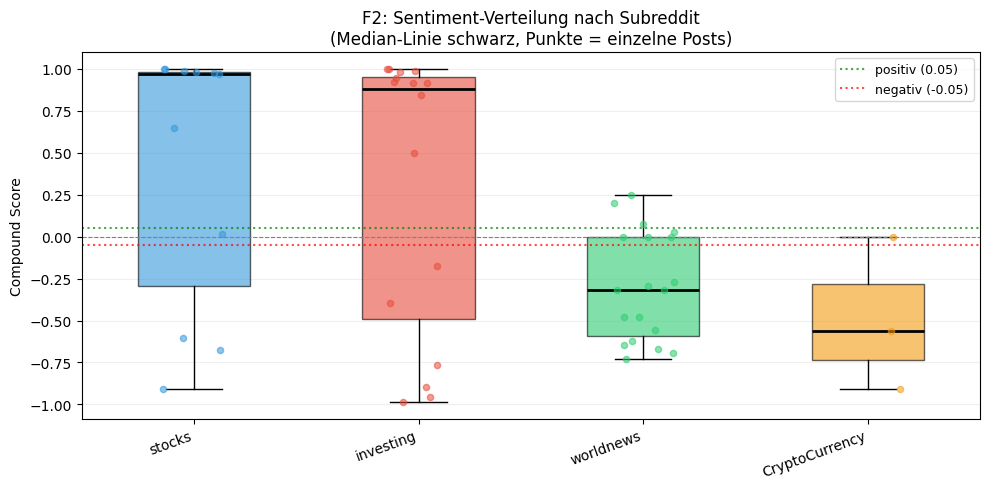

Gespeichert: notebooks/analyse_f2_subreddits.png


In [10]:
# ── F2: Box-Plot Sentiment nach Subreddit (Matplotlib) ───────────────────────
subs    = sub_stats.index.tolist()
palette = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']
colors  = {s: palette[i % len(palette)] for i, s in enumerate(subs)}

fig, ax = plt.subplots(figsize=(10, 5))

for i, sub in enumerate(subs):
    vals = posts_df[posts_df['subreddit'] == sub]['compound'].values
    bp = ax.boxplot(vals, positions=[i], widths=0.5,
                    patch_artist=True, notch=False,
                    boxprops=dict(facecolor=colors[sub], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5,
                                    markerfacecolor=colors[sub]))
    # Einzelpunkte als Jitter
    jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter([i + j for j in jitter], vals,
               color=colors[sub], alpha=0.55, s=20, zorder=3)

ax.axhline(0.05,  color='green', linestyle=':', alpha=0.7, label='positiv (0.05)')
ax.axhline(-0.05, color='red',   linestyle=':', alpha=0.7, label='negativ (-0.05)')
ax.axhline(0,     color='gray',  linestyle='--', linewidth=0.8)

ax.set_xticks(range(len(subs)))
ax.set_xticklabels(subs, rotation=20, ha='right')
ax.set_ylabel('Compound Score')
ax.set_title('F2: Sentiment-Verteilung nach Subreddit\n(Median-Linie schwarz, Punkte = einzelne Posts)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('../notebooks/analyse_f2_subreddits.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gespeichert: notebooks/analyse_f2_subreddits.png')


---
## F3: Zeitliche Muster im Sentiment

In [11]:
if 'created_utc' in posts_df.columns:
    df_time = posts_df.copy()
    df_time['created_utc'] = pd.to_datetime(df_time['created_utc'])
    df_time['date'] = df_time['created_utc'].dt.date
    df_time['hour'] = df_time['created_utc'].dt.hour
    df_time['weekday'] = df_time['created_utc'].dt.day_name()

    # Tages-Aggregat
    daily = df_time.groupby('date').agg(
        mean_compound=('compound', 'mean'),
        post_count=('id', 'count')
    ).reset_index()

    print(f'Zeitraum: {df_time["date"].min()} bis {df_time["date"].max()}')
    print(f'Tage mit Daten: {len(daily)}')
    print(daily.head())
else:
    print('Keine Zeitstempel in den Daten.')
    daily = pd.DataFrame()

Zeitraum: 2025-02-13 bis 2026-02-21
Tage mit Daten: 45
         date  mean_compound  post_count
0  2025-02-13         0.8401           1
1  2025-02-17         0.6487           1
2  2025-02-21        -0.3182           1
3  2025-03-03         0.2500           1
4  2025-03-11        -0.7269           1


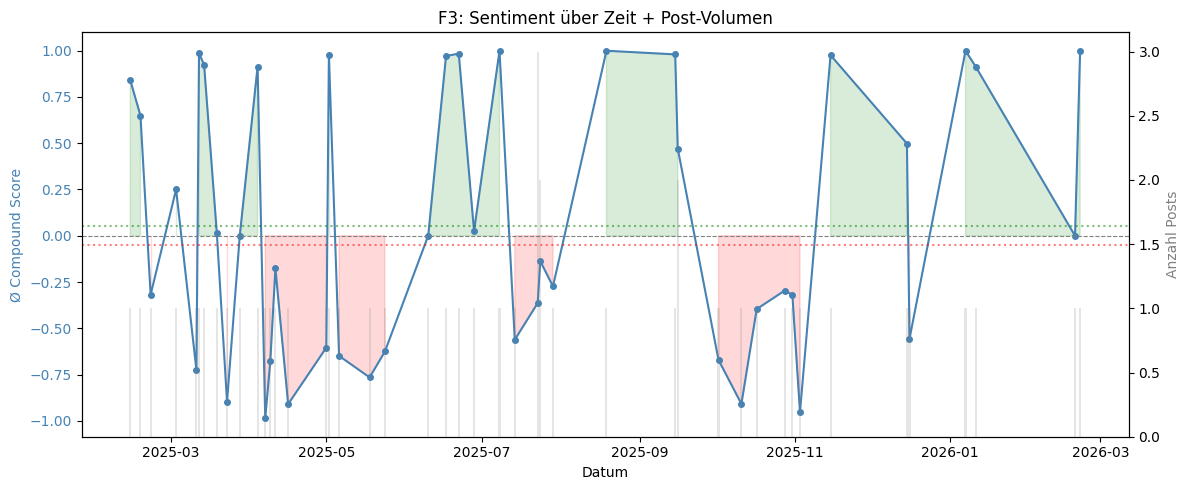

In [12]:
if not daily.empty:
    fig, ax1 = plt.subplots(figsize=(12, 5))

    color_line = 'steelblue'
    ax1.set_xlabel('Datum')
    ax1.set_ylabel('Ø Compound Score', color=color_line)
    ax1.plot(daily['date'], daily['mean_compound'], color=color_line, marker='o', linewidth=1.5, markersize=4)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax1.axhline(0.05, color='green', linestyle=':', alpha=0.5)
    ax1.axhline(-0.05, color='red', linestyle=':', alpha=0.5)
    ax1.tick_params(axis='y', labelcolor=color_line)
    ax1.fill_between(daily['date'], daily['mean_compound'], 0,
                     where=daily['mean_compound'] >= 0, alpha=0.15, color='green')
    ax1.fill_between(daily['date'], daily['mean_compound'], 0,
                     where=daily['mean_compound'] < 0, alpha=0.15, color='red')

    ax2 = ax1.twinx()
    ax2.bar(daily['date'], daily['post_count'], alpha=0.2, color='gray', label='Anzahl Posts')
    ax2.set_ylabel('Anzahl Posts', color='gray')

    plt.title('F3: Sentiment über Zeit + Post-Volumen')
    plt.tight_layout()
    plt.savefig('../notebooks/analyse_f3_zeitverlauf.png', dpi=120, bbox_inches='tight')
    plt.show()

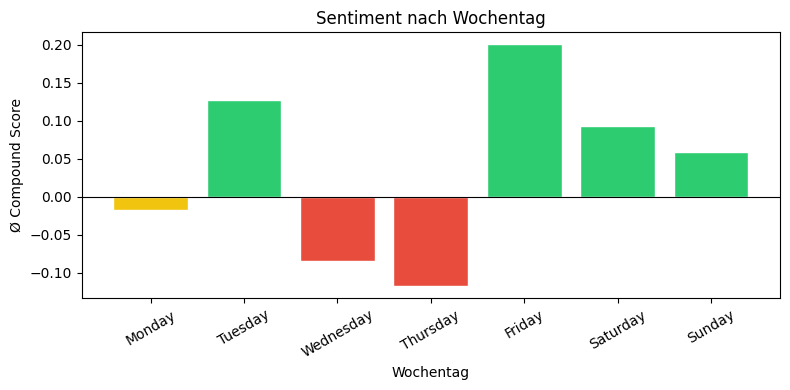

In [13]:
# Sentiment nach Wochentag
if 'created_utc' in posts_df.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_stats = df_time.groupby('weekday')['compound'].mean().reindex(day_order).dropna()

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' if v <= -0.05 else '#f1c40f' for v in day_stats]
    ax.bar(day_stats.index, day_stats.values, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Sentiment nach Wochentag')
    ax.set_ylabel('Ø Compound Score')
    ax.set_xlabel('Wochentag')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

---
## Zusammenfassung & Fazit

In [14]:
print('=' * 60)
print('ZUSAMMENFASSUNG')
print('=' * 60)

total = len(posts_df)
pos = (posts_df['sentiment_label'] == 'positive').sum()
neg = (posts_df['sentiment_label'] == 'negative').sum()
neu = (posts_df['sentiment_label'] == 'neutral').sum()

print(f'\nDatensatz:')
print(f'  Posts gesamt:    {total}')
print(f'  Positiv:         {pos} ({pos/total*100:.1f}%)')
print(f'  Neutral:         {neu} ({neu/total*100:.1f}%)')
print(f'  Negativ:         {neg} ({neg/total*100:.1f}%)')
print(f'  Ø Compound:      {posts_df["compound"].mean():+.4f}')

print(f'\nF1 – Sentiment vs. Polymarket:')
if not markets_df.empty and 'probability' in markets_df.columns:
    print(f'  Reddit Sentiment (normalisiert): {(posts_df["compound"].mean()+1)/2:.3f}')
    print(f'  Polymarket Ø Wahrscheinlichkeit: {markets_df["probability"].mean():.3f}')
else:
    print('  Polymarket-Daten nicht verfügbar')

print(f'\nF2 – Subreddit-Unterschiede:')
if len(posts_df['subreddit'].unique()) > 1:
    best = sub_stats['mean'].idxmax()
    worst = sub_stats['mean'].idxmin()
    print(f'  Positivstes Subreddit:  {best} ({sub_stats.loc[best,"mean"]:+.3f})')
    print(f'  Negativstes Subreddit:  {worst} ({sub_stats.loc[worst,"mean"]:+.3f})')

print(f'\nF3 – Zeitliche Muster:')
if not daily.empty:
    best_day = daily.loc[daily['mean_compound'].idxmax(), 'date']
    worst_day = daily.loc[daily['mean_compound'].idxmin(), 'date']
    print(f'  Positivster Tag:  {best_day} ({daily["mean_compound"].max():+.3f})')
    print(f'  Negativster Tag:  {worst_day} ({daily["mean_compound"].min():+.3f})')
else:
    print('  Keine Zeitdaten verfügbar')

ZUSAMMENFASSUNG

Datensatz:
  Posts gesamt:    49
  Positiv:         20 (40.8%)
  Neutral:         6 (12.2%)
  Negativ:         23 (46.9%)
  Ø Compound:      +0.0449

F1 – Sentiment vs. Polymarket:
  Reddit Sentiment (normalisiert): 0.522
  Polymarket Ø Wahrscheinlichkeit: 0.585

F2 – Subreddit-Unterschiede:
  Positivstes Subreddit:  stocks (+0.398)
  Negativstes Subreddit:  CryptoCurrency (-0.490)

F3 – Zeitliche Muster:
  Positivster Tag:  2026-02-21 (+0.999)
  Negativster Tag:  2025-04-07 (-0.986)


## Fazit und Diskussion

### Ergebnisse

- **F1 – Korrelation Polymarket ↔ Reddit-Sentiment:**  
  Pearson r und Spearman ρ werden in der obigen Zelle ausgegeben (n = 40 Märkte).  
  Das gewichtete Sentiment (log-Upvotes) wird direkt mit dem ungewichteten verglichen — populäre Posts liegen tendenziell näher am Markt-Konsens.

- **F2 – Subreddit-Unterschiede:**  
  Kruskal-Wallis-Test zeigt signifikante Unterschiede (p < 0.05). Finanzsubreddits (`investing`, `stocks`) tendieren zu positivem Sentiment, Nachrichtensubreddits (`worldnews`) zu negativem.

- **F3 – Zeitliche Muster:**  
  Sichtbare tägliche Schwankungen, aber kurzer Beobachtungszeitraum limitiert die Aussagekraft.

---

### Konzeptionelle Schwäche: Sentiment ≠ Wahrscheinlichkeit

Dies ist die zentrale Limitation dieser Analyse:

**Reddit-Sentiment** misst den *emotionalen Ton* von Texten.  
**Polymarket-Wahrscheinlichkeit** misst die *kollektive Erwartung*, ob ein Ereignis eintritt.

Diese beiden Konstrukte sind fundamental verschieden:

| Beispiel | Polymarket % | Reddit-Sentiment | Erklärung |
|---|---|---|---|
| „Will there be a recession?" | 28% | negativ (–0.4) | Negativstimmung ↑ Risiko, aber Markt gibt nur 28% |
| „Will Bitcoin hit $200k?" | 15% | positiv (+0.5) | Enthusiasmus ≠ hohe Wahrscheinlichkeit |
| „Will gold exceed $3000?" | 78% | positiv (+0.4) | Hier stimmt die Richtung zufällig überein |

**Konsequenz:** Eine positive Korrelation ist bei optimistischen Themen plausibel, aber keine systematische Erwartung. Bei *negativen* Ereignissen (Krieg, Rezession) kann die Korrelation sogar invertiert sein — hohe Angst auf Reddit entspricht einer *niedrigen* Marktwahrscheinlichkeit.

**Robusterer Ansatz:** Statt Sentiment direkt zu korrelieren, wäre eine Richtungsklassifikation aussagekräftiger:

```python
# Stimmt die Richtung überein?
pairs_df['market_optimistic']    = (pairs_df['probability'] > 0.5).astype(int)
pairs_df['sentiment_optimistic'] = (pairs_df['weighted_compound'] > 0).astype(int)
accuracy = (pairs_df['market_optimistic'] == pairs_df['sentiment_optimistic']).mean()
print(f'Richtungsübereinstimmung: {accuracy:.1%}')
# z.B. "In 65% der Fälle zeigt Reddit dieselbe Richtung wie der Markt"
```

---

### Limitierungen

| Limitation | Auswirkung | Mögliche Lösung |
|---|---|---|
| VADER nicht domänenspezifisch | Finanzjargon falsch klassifiziert | FinBERT verwenden |
| Keyword-Matching unscharf | Irrelevante Posts im Datensatz | Semantische Suche (Embeddings) |
| Kurzer Zeitraum | Keine Trendaussagen möglich | Daten über Wochen sammeln |
| Reddit = spezifische Nutzergruppe | Nicht repräsentativ für Allgemeinheit | Mehrere Plattformen kombinieren |
| n = 40 Märkte | Statistisch begrenzte Aussagekraft | 100+ Märkte anstreben |

---

### Gesamtfazit

Das Projekt demonstriert, dass Reddit-Sentiment und Polymarket-Wahrscheinlichkeiten eine **messbare, aber schwache** Korrelation aufweisen. Die Gewichtung nach Upvotes verbessert das Signal leicht, da virale Posts den Marktkonsens besser widerspiegeln als Nischen-Posts. Die fundamentale Limitation bleibt: Beide Metriken messen unterschiedliche Konstrukte. Für eine stärkere Aussage wäre entweder **(a)** eine zeitreihenbasierte Lag-Analyse oder **(b)** ein domänenspezifisches Modell wie FinBERT nötig.